# Danish National Election Survey
The purpose of this notebook is to read and recode the answers of the DNES for 2022 to match a format that can then be raked.

Variables can be found here: https://digidata.rigsarkivet.dk/aflevering/51035/table/fv22_main_8feb2024

This is not the full coding, and the rest of the questions can be seen in data/questions.pdf

In [3]:
import pandas as pd
import requests
from tqdm import tqdm
tqdm.pandas()
df = pd.read_csv('data/DNES_2022.csv', sep=',')
print(len(df.index))
print(df.columns)
df.head()

2823
Index(['sample', 'gender', 'birthyear', 'Q3', 'Q4', 'Q5', 'Q5_o1', 'Q5b_1',
       'Q5b_2', 'Q5b_3',
       ...
       'Q6_problem', 'Q7_problem', 'Q8_problem', 'Q9_problem', 'weight_1',
       'weight_2', 'weight_3', 'weight_4', 'weight_5', 'L�benummer'],
      dtype='object', length=467)


,sample,gender,birthyear,Q3,Q4,Q5,Q5_o1,Q5b_1,Q5b_2,Q5b_3,...,Q6_problem,Q7_problem,Q8_problem,Q9_problem,weight_1,weight_2,weight_3,weight_4,weight_5,L�benummer
0,1,2,1993.0,3.0,4.0,2.0,NaN,NaN,NaN,NaN,...,3,9,9,9,1.200782,0.925824,1.348964,1.468959,1.000000,2790
1,1,1,1933.0,5.0,4.0,1.0,NaN,NaN,NaN,NaN,...,845,870,850,650,0.662772,0.696920,0.849662,1.203742,0.846962,2364
2,1,2,1939.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,...,650,800,3,9,1.074965,0.888480,1.058984,1.203742,1.030258,632
3,1,2,1942.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,...,845,700,660,3,1.074965,0.888480,1.058984,1.203742,1.030258,183
4,1,1,1942.0,3.0,4.0,1.0,NaN,NaN,NaN,NaN,...,3,3,9,9,0.542676,0.696920,0.584294,0.875487,0.950831,1699


In [4]:
df['kommunekode'].sample(10).values


array([161., 779., 787., 461., 510., 370., 461., 430., 746., 173.])

In [5]:
def get_municipality_name(code):
    if pd.isna(code):
        return None
    code_int = int(float(code))          
    formatted_code = f"{code_int:04d}"   # zero‑pad to 4 digits

    url = f"https://api.dataforsyningen.dk/kommuner/{formatted_code}"
    response = requests.get(url)
    if response.status_code == 200:
        return response.json().get('navn')
    return "Unknown"

sample = df['kommunekode'].sample(5).values
for code in sample:
    print(f"Code: {code}, Municipality: {get_municipality_name(code)}")

Code: 370.0, Municipality: Næstved
Code: 791.0, Municipality: Viborg
Code: 101.0, Municipality: København
Code: 710.0, Municipality: Favrskov
Code: 730.0, Municipality: Randers


In [6]:
# dicts to recode, the name of the var is the same as the name of the column
# the comment next to the dict definition is the name of the column in the recoded col
gender = { #gender
    1: 'Men',
    2: 'Women',
    3: 'Other'
}

Q3 = { #marital_status
    1: 'Married',
    2: 'Divorced',
    3: 'Single',
    4: 'In a steady relationship',
    5: 'Widow/widower'
}

Q4 = { #living_situation
    1: 'Living with spouse',
    2: 'Living with cohabitant',
    3: 'Living with other adults',
    4: 'Living alone'
}

Q11 = { #interest_in_politics
    1: 'Very interested',
    2: 'Somewhat interested',
    3: 'Only slightly interested',
    4: 'Not at all interested',
    99: 'Don\'t know'
}

Q14 = { #days_per_week_tv_news
    # 1-7 are all translatable, 99 is 'Don't know'
    99: 'Don\'t know'
}

Q15 = { #days_per_week_newspaper
    99: 'Don\'t know'
}

Q16 = { #turnout_in_2022
    1: 'Voted',
    2: 'Considered voting, did not vote',
    3: 'I usually vote, did not vote',
    4: 'I did not vote'
}

Q17 = { #vote_in_2022
    1: 'A: Socialdemokratiet',
    2: 'B: Det Radikale Venstre',
    3: 'C: Det Konservative Folkeparti',
    4: 'D: Nye Borgerlige',
    6: 'F: SF - Socialistisk Folkeparti',
    9: 'I: Liberal Alliance',
    11: 'K: Kristendemokraterne',
    13: 'M: Moderaterne',
    15: 'O: Dansk Folkeparti',
    17: 'Q: Frie Grønne',
    22: 'V: Venstre',
    27: 'Æ: Danmarksdemokraterne',
    28: 'Ø: Enhedslisten',
    29: 'Å: Alternativet',
    30: 'Another party',
    31: 'Independent candidate',
    32: 'Voted blank',
    33: 'Did not vote',
    99: 'Don\'t know'
}

Q22 = { #vote_in_2019
    1: 'A: Socialdemokraterne',
    2: 'B: Det Radikale Venstre',
    3: 'C: Det Konservative Folkeparti',
    4: 'D: Nye Borgerlige',
    5: 'E: Klaus Riskær Pedersen',
    6: 'F: SF - Socialistisk Folkeparti',
    9: 'I: Liberal Alliance',
    11: 'K: Kristendemokraterne',
    15: 'O: Dansk Folkeparti',
    16: 'P: Stram Kurs',
    22: 'V: Venstre',
    28: 'Ø: Enhedslisten',
    29: 'Å: Alternativet',
    30: 'Other party',
    31: 'Independent candidate',
    32: 'Voted blank',
    33: 'Did not vote',
    99: 'Don\'t know'
}

Q29 = { #party_attachment_strength
    1: 'Strongly convinced supporter',
    2: 'Not strongly convinced supporter',
    99: 'Don\'t know'
}

Q32 = { #class_differences_perception
    1: 'Yes',
    2: 'No',
    99: 'Don\'t know'
}

Q78 = { #gross_annual_income
    1: 'Under 100,000 kr.',
    2: '100,000-149,999 kr.',
    3: '150,000-199,999 kr.',
    4: '200,000-249,999 kr.',
    5: '250,000-299,999 kr.',
    6: '300,000-349,999 kr.',
    7: '350,000-399,999 kr.',
    8: '400,000-449,999 kr.',
    9: '450,000-499,999 kr.',
    10: '500,000-599,999 kr.',
    11: '600,000-699,999 kr.',
    12: '700,000-799,999 kr.',
    13: '800,000-999,999 kr.',
    14: '1,000,000-1,199,999 kr.',
    15: '1,200,000 kr. or more',
    99: 'Don\'t know'
}

Q83 = { #economic_security
    1: 'Very secure',
    2: 'Secure',
    3: 'Neither secure nor insecure',
    4: 'Insecure',
    5: 'Very insecure',
    99: 'Don\'t know'
}

Q87 = { #social_class_identity
    1: 'Working class',
    2: 'Middle class',
    99: 'Don\'t know'
}

Q93 = { #union_membership
    1: 'Yes, member of a labor union',
    2: 'No, not a member',
    99: 'Don\'t know'
}

Q104 = { #employment_sector
    1: 'Privately employed',
    2: 'Publicly employed',
    3: 'Self-employed',
    4: 'Other/Not in workforce',
    99: 'Don\'t know'
}

Q90 = { #school_education
    1: 'H1010 Primary school through to 6th grade', 2: 'H1020 Primary school 7th-9th grade', 3: 'H1030 Primary school 10th grade',
    4: 'H2010 Upper secondary education, General (stx, hf, student courses)', 5: 'H2010 Upper secondary education, General (stx, hf, student courses)', 6: 'H2010 Upper secondary education, General (stx, hf, student courses)', 7: 'H2020 Upper secondary education, General (hhx, htx)', 8: 'H2020 Upper secondary education, General (hhx, htx)', 9: 'H30 Vocational Education and Training (VET)',
    10: 'H90 Not stated', 11: 'H90 Not stated', 99: 'H90 Not stated'
}

# question 91 asks if the respondent has completed higher education
# if they answer 1: 'Yes', then question their answer for question 92 is their highest education
# otherwise; their highest education is their answer in Q90

Q92 = { #higher_education
    1: 'H30 Vocational Education and Training (VET)',
    2: 'H30 Vocational Education and Training (VET)',
    3: 'H30 Vocational Education and Training (VET)',
    4: 'H30 Vocational Education and Training (VET)',
    5: 'H30 Vocational Education and Training (VET)',
    6: 'H30 Vocational Education and Training (VET)',
    7: 'H40 Short cycle higher education',
    8: 'H50 Vocational bachelors educations',
    9: 'H60 Bachelors programs',
    10: 'H70 Masters programs',
    11: 'H90 Not stated',
    99: 'H90 Not stated',
}



In [7]:
#these are just to rename the columns if the answer to a question is a number
columns = {
    'Q5': 'number_of_children',
}

In [8]:
# Map from dict variable name → (source column in df, new column name)
recode_map = {
    'gender':  ('gender',  'gender'),
    'Q3':      ('Q3',      'marital_status'),
    'Q4':      ('Q4',      'living_situation'),
    'Q11':     ('Q11',     'interest_in_politics'),
    'Q14':     ('Q14_1',   'days_per_week_tv_news'),
    'Q15':     ('Q15_1',   'days_per_week_newspaper'),
    'Q16':     ('Q16',     'turnout_in_2022'),
    'Q17':     ('Q17',     'vote_in_2022'),
    'Q22':     ('Q22',     'vote_in_2019'),
    'Q29':     ('Q29',     'party_attachment_strength'),
    'Q32':     ('Q32',     'class_differences_perception'),
    'Q78':     ('Q78',     'gross_annual_income'),
    'Q83':     ('Q83',     'economic_security'),
    'Q87':     ('Q87',     'social_class_identity'),
    'Q93':     ('Q93',     'union_membership'),
    'Q104':    ('Q104',    'employment_sector'),
    'Q90':     ('Q90',     'school_education'),
    'Q92':     ('Q92',     'higher_education'),
}

# All recode dicts by name
recode_dicts = {
    'gender': gender, 'Q3': Q3, 'Q4': Q4, 'Q11': Q11,
    'Q14': Q14, 'Q15': Q15, 'Q16': Q16, 'Q17': Q17,
    'Q22': Q22, 'Q29': Q29, 'Q32': Q32, 'Q78': Q78,
    'Q83': Q83, 'Q87': Q87, 'Q93': Q93, 'Q104': Q104, 'Q90': Q90,
    'Q92': Q92
}

# Build the recoded dataframe
df_recoded = pd.DataFrame()

# Add birthyear and age
df_recoded['birthyear'] = df['birthyear']
df_recoded['age'] = 2026 - df['birthyear']

df_recoded['municipality'] = df['kommunekode'].progress_apply(get_municipality_name)
df_recoded['mun_code'] = df['kommunekode']

# Add number_of_children (numeric, just rename)
df_recoded['number_of_children'] = df['Q5']

# add q91 as a col
df_recoded['Q91'] = df['Q91']

# # get education_level based on Q91, Q90, and Q92
# def get_education_level(row):
#     if row['Q91'] == 1: # if they have completed higher education, use Q92
#         return Q92.get(row['92'], 'Unknown')
#     else: # otherwise, use Q90
#         return Q90.get(row['school_education'], 'Unknown')

# df_recoded['education_level'] = df.apply(get_education_level, axis=1)

# Recode each question
for dict_name, (src_col, new_col) in recode_map.items():
    mapping = recode_dicts[dict_name]
    mapped = df[src_col].map(mapping)
    df_recoded[new_col] = mapped.where(mapped.notna(), df[src_col])

print(f"Shape: {df_recoded.shape}")
df_recoded.head()

100%|██████████| 2823/2823 [06:35<00:00,  7.13it/s]

Shape: (2823, 24)


,birthyear,age,municipality,mun_code,number_of_children,Q91,gender,marital_status,living_situation,interest_in_politics,...,vote_in_2019,party_attachment_strength,class_differences_perception,gross_annual_income,economic_security,social_class_identity,union_membership,employment_sector,school_education,higher_education
0,1993.0,33.0,None,NaN,2.0,NaN,Women,Single,Living alone,Not at all interested,...,Did not vote,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1933.0,93.0,København,101.0,1.0,4.0,Men,Widow/widower,Living alone,Very interested,...,A: Socialdemokraterne,Not strongly convinced supporter,NaN,"150,000-199,999 kr.",Secure,NaN,"No, not a member",Publicly employed,"H2010 Upper secondary education, General (stx,...",H30 Vocational Education and Training (VET)
2,1939.0,87.0,København,101.0,2.0,1.0,Women,Married,Living with spouse,Very interested,...,A: Socialdemokraterne,Strongly convinced supporter,Yes,"100,000-149,999 kr.",Very secure,NaN,"No, not a member",Self-employed,"H2010 Upper secondary education, General (stx,...",H30 Vocational Education and Training (VET)
3,1942.0,84.0,København,101.0,2.0,1.0,Women,Married,Living with spouse,Somewhat interested,...,A: Socialdemokraterne,Strongly convinced supporter,Yes,"300,000-349,999 kr.",Very secure,NaN,"Yes, member of a labor union",Self-employed,"H2010 Upper secondary education, General (stx,...",H30 Vocational Education and Training (VET)
4,1942.0,84.0,København,101.0,1.0,1.0,Men,Single,Living alone,Only slightly interested,...,A: Socialdemokraterne,Not strongly convinced supporter,Yes,"300,000-349,999 kr.",Neither secure nor insecure,Middle class,"No, not a member",Self-employed,"H2010 Upper secondary education, General (stx,...",H40 Short cycle higher education


In [26]:
# Use higher_education when available; otherwise fall back to school_education
if 'highest_education' in df_recoded.columns:
    primary_col = 'highest_education'
else:
    primary_col = 'higher_education'

df_recoded['education_level'] = df_recoded[primary_col].combine_first(df_recoded['school_education'])

In [27]:
# recode København to Copenhagen
df_recoded['municipality'] = df_recoded['municipality'].replace('København', 'Copenhagen')

In [28]:
# Fill in "Did not vote" in vote_in_2022 based on turnout_in_2022 responses
non_voter_conditions = ['I did not vote', 'I usually vote, did not vote']
mask = df_recoded['turnout_in_2022'].isin(non_voter_conditions)
df_recoded.loc[mask, 'vote_in_2022'] = 'Did not vote'

In [29]:
df_recoded.to_csv('data/DNES_2022_recoded.csv')

In [30]:
df_recoded = pd.read_csv('data/DNES_2022_recoded.csv')
df_recoded

,Unnamed: 0.1,Unnamed: 0,birthyear,age,municipality,mun_code,number_of_children,Q91,gender,marital_status,...,class_differences_perception,gross_annual_income,economic_security,social_class_identity,union_membership,employment_sector,school_education,higher_education,education_level,vote_pct
0,0,0,1993.0,33.0,NaN,NaN,2.0,NaN,Women,Single,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,1933.0,93.0,Copenhagen,101.0,1.0,4.0,Men,Widow/widower,...,NaN,"150,000-199,999 kr.",Secure,NaN,"No, not a member",Publicly employed,"H2010 Upper secondary education, General (stx,...",H30 Vocational Education and Training (VET),H30 Vocational Education and Training (VET),NaN
2,2,2,1939.0,87.0,Copenhagen,101.0,2.0,1.0,Women,Married,...,Yes,"100,000-149,999 kr.",Very secure,NaN,"No, not a member",Self-employed,"H2010 Upper secondary education, General (stx,...",H30 Vocational Education and Training (VET),H30 Vocational Education and Training (VET),0.147549
3,3,3,1942.0,84.0,Copenhagen,101.0,2.0,1.0,Women,Married,...,Yes,"300,000-349,999 kr.",Very secure,NaN,"Yes, member of a labor union",Self-employed,"H2010 Upper secondary education, General (stx,...",H30 Vocational Education and Training (VET),H30 Vocational Education and Training (VET),0.147549
4,4,4,1942.0,84.0,Copenhagen,101.0,1.0,1.0,Men,Single,...,Yes,"300,000-349,999 kr.",Neither secure nor insecure,Middle class,"No, not a member",Self-employed,"H2010 Upper secondary education, General (stx,...",H40 Short cycle higher education,H40 Short cycle higher education,0.076480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,2818,2818,1984.0,42.0,Hjørring,860.0,1.0,1.0,Women,Married,...,Yes,"350,000-399,999 kr.",Secure,NaN,"Yes, member of a labor union",NaN,"H2010 Upper secondary education, General (stx,...",H50 Vocational bachelors educations,H50 Vocational bachelors educations,0.293844
2819,2819,2819,1988.0,38.0,Hjørring,860.0,1.0,NaN,Women,Married,...,NaN,"200,000-249,999 kr.",Insecure,Working class,"Yes, member of a labor union",Privately employed,H90 Not stated,NaN,H90 Not stated,0.293844
2820,2820,2820,1988.0,38.0,Hjørring,860.0,1.0,1.0,Women,Married,...,Yes,"300,000-349,999 kr.",Secure,NaN,"No, not a member",NaN,"H2010 Upper secondary education, General (stx,...",H30 Vocational Education and Training (VET),H30 Vocational Education and Training (VET),NaN
2821,2821,2821,1994.0,32.0,Hjørring,860.0,2.0,3.0,Men,Single,...,Yes,"100,000-149,999 kr.",Very insecure,Working class,"Yes, member of a labor union",Privately employed,H1030 Primary school 10th grade,NaN,H1030 Primary school 10th grade,0.040054


<Axes: ylabel='vote_in_2022'>

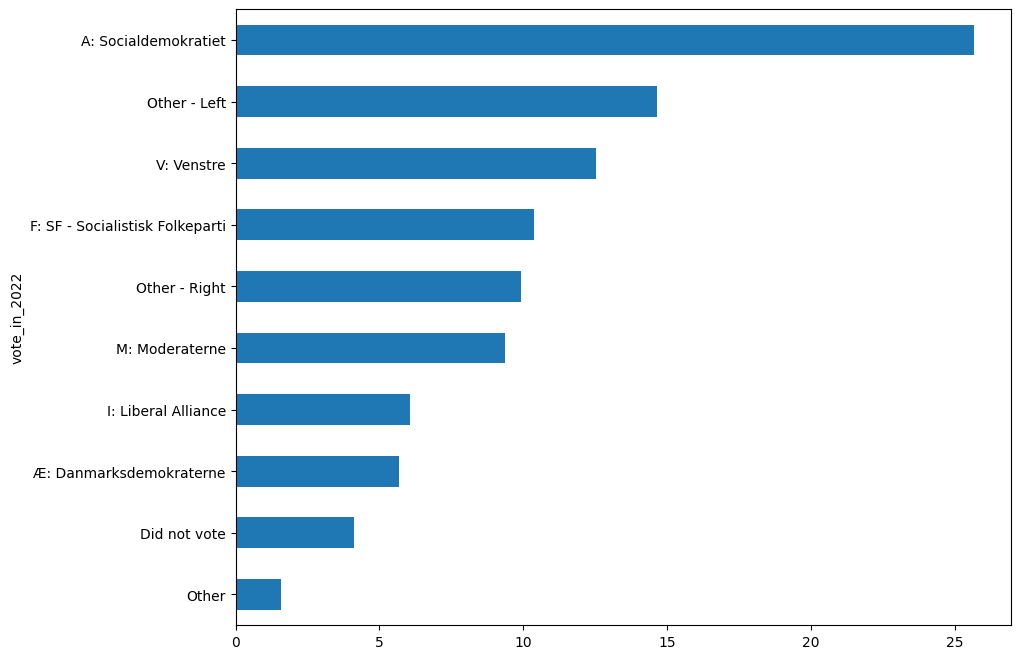

In [31]:
vote_data = df_recoded['vote_in_2022'].dropna()

vote_counts = vote_data.value_counts()
vote_pct = (vote_counts / vote_counts.sum() * 100).sort_values(ascending=True)

vote_pct.plot(kind='barh', figsize=(10, 8))

In [32]:
party_colors = {
    "A: Socialdemokratiet": "#C82518",           #
    "V: Venstre": "#01438E",                     #
    "F: SF - Socialistisk Folkeparti": "#eb94d1", # Green Left
    "M: Moderaterne": "#B48CD2",                 #
    "I: Liberal Alliance": "#3FB2BE",            #
    "Ø: Enhedslisten": "#F7660D",                # Red-Green
    "C: Det Konservative Folkeparti": "#6B9249", # Conservatives
    "Æ: Danmarksdemokraterne": "#668DD1",        #
    "B: Det Radikale Venstre": "#733280",        # Social Liberals
    "Å: Alternativet": "#18942D",                # The Alternative
    "D: Nye Borgerlige": "#00505B",              # New Right
    "O: Dansk Folkeparti": "#FCD03B",            # DPP
    "Q: Frie Grønne": "#66ba92",                 # Independent Greens
    "K: Kristendemokraterne": "#53619B",         # Christian Democrats
    "Independent candidate": "#cccccc",          # Default grey
    "Another party": "#eeeeee"                   # Default light grey
}

In [33]:
print(f"Options in 2019: {len(df_recoded['vote_in_2019'].dropna().unique())}")
print(f"Options in 2022: {len(df_recoded['vote_in_2022'].dropna().unique())}")

Options in 2019: 17
Options in 2022: 10


In [41]:
def age_to_group(age):
    if pd.isna(age):
        return None
    age = int(age)
    if age < 15:
        return None
    elif age < 20:
        return '15-19'
    elif age < 25:
        return '20-24'
    elif age < 30:
        return '25-29'
    elif age < 35:
        return '30-34'
    elif age < 40:
        return '35-39'
    elif age < 45:
        return '40-44'
    elif age < 50:
        return '45-49'
    elif age < 55:
        return '50-54'
    elif age < 60:
        return '55-59'
    elif age < 65:
        return '60-64'
    elif age < 70:
        return '65-69'
    elif age < 75:
        return '70-74'
    elif age < 80:
        return '75-79'
    elif age < 85:
        return '80-84'
    elif age < 90:
        return '85-89'
    elif age < 95:
        return '90-94'
    elif age < 100:
        return '100+'
df_recoded['age_group'] = df_recoded['age'].apply(age_to_group)
print(df_recoded['age_group'].unique())



['30-34' '90-94' '85-89' '80-84' '75-79' '70-74' '65-69' '60-64' '55-59'
 '50-54' '45-49' '40-44' '35-39' '25-29' '20-24' None]


In [35]:
sample_cols = ['age_group', 'gender', 'municipality', 'education_level', 'vote_in_2022']
df_recoded[sample_cols].sample(10)

,age_group,gender,municipality,education_level,vote_in_2022
1470,40-44,Men,Odense,H60 Bachelors programs,I: Liberal Alliance
2300,55-59,Men,Aarhus,H70 Masters programs,Did not vote
1020,60-64,Women,Gribskov,"H2010 Upper secondary education, General (stx,...",Other - Left
1534,70-74,Men,Nordfyns,H1020 Primary school 7th-9th grade,M: Moderaterne
2294,60-64,Women,Aarhus,H50 Vocational bachelors educations,M: Moderaterne
1428,60-64,Women,Odense,"H2010 Upper secondary education, General (stx,...",M: Moderaterne
1657,75-79,Women,Esbjerg,H30 Vocational Education and Training (VET),A: Socialdemokratiet
1339,65-69,Men,Faaborg-Midtfyn,H50 Vocational bachelors educations,F: SF - Socialistisk Folkeparti
1150,25-29,Women,Slagelse,H90 Not stated,M: Moderaterne
1389,80-84,Men,Odense,H30 Vocational Education and Training (VET),A: Socialdemokratiet


In [36]:
votes = pd.read_csv('data/denmark_election_results_with_turnout.csv')
votes = votes[votes['year'] == 2022]
df_recoded = pd.read_csv('data/DNES_2022_recoded.csv')
df_recoded['municipality'] = df_recoded['municipality'].replace({'København': 'Copenhagen'})
df_recoded = df_recoded.merge(
    votes[['party', 'municipality', 'pop_pct']],
    left_on=['vote_in_2022', 'municipality'],
    right_on=['party', 'municipality'],
    how='left'
).rename(columns={'pop_pct': 'vote_pct'}).drop(columns=['party'])

df_recoded


,Unnamed: 0.1,Unnamed: 0,birthyear,age,municipality,mun_code,number_of_children,Q91,gender,marital_status,...,gross_annual_income,economic_security,social_class_identity,union_membership,employment_sector,school_education,higher_education,education_level,vote_pct,vote_pct
0,0,0,1993.0,33.0,NaN,NaN,2.0,NaN,Women,Single,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,1933.0,93.0,Copenhagen,101.0,1.0,4.0,Men,Widow/widower,...,"150,000-199,999 kr.",Secure,NaN,"No, not a member",Publicly employed,"H2010 Upper secondary education, General (stx,...",H30 Vocational Education and Training (VET),H30 Vocational Education and Training (VET),NaN,0.299313
2,2,2,1939.0,87.0,Copenhagen,101.0,2.0,1.0,Women,Married,...,"100,000-149,999 kr.",Very secure,NaN,"No, not a member",Self-employed,"H2010 Upper secondary education, General (stx,...",H30 Vocational Education and Training (VET),H30 Vocational Education and Training (VET),0.147549,0.147549
3,3,3,1942.0,84.0,Copenhagen,101.0,2.0,1.0,Women,Married,...,"300,000-349,999 kr.",Very secure,NaN,"Yes, member of a labor union",Self-employed,"H2010 Upper secondary education, General (stx,...",H30 Vocational Education and Training (VET),H30 Vocational Education and Training (VET),0.147549,0.147549
4,4,4,1942.0,84.0,Copenhagen,101.0,1.0,1.0,Men,Single,...,"300,000-349,999 kr.",Neither secure nor insecure,Middle class,"No, not a member",Self-employed,"H2010 Upper secondary education, General (stx,...",H40 Short cycle higher education,H40 Short cycle higher education,0.076480,0.076480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,2818,2818,1984.0,42.0,Hjørring,860.0,1.0,1.0,Women,Married,...,"350,000-399,999 kr.",Secure,NaN,"Yes, member of a labor union",NaN,"H2010 Upper secondary education, General (stx,...",H50 Vocational bachelors educations,H50 Vocational bachelors educations,0.293844,0.293844
2819,2819,2819,1988.0,38.0,Hjørring,860.0,1.0,NaN,Women,Married,...,"200,000-249,999 kr.",Insecure,Working class,"Yes, member of a labor union",Privately employed,H90 Not stated,NaN,H90 Not stated,0.293844,0.293844
2820,2820,2820,1988.0,38.0,Hjørring,860.0,1.0,1.0,Women,Married,...,"300,000-349,999 kr.",Secure,NaN,"No, not a member",NaN,"H2010 Upper secondary education, General (stx,...",H30 Vocational Education and Training (VET),H30 Vocational Education and Training (VET),NaN,0.044969
2821,2821,2821,1994.0,32.0,Hjørring,860.0,2.0,3.0,Men,Single,...,"100,000-149,999 kr.",Very insecure,Working class,"Yes, member of a labor union",Privately employed,H1030 Primary school 10th grade,NaN,H1030 Primary school 10th grade,0.040054,0.040054


In [37]:
# print all unique parties
print(df_recoded['vote_in_2022'].dropna().unique())

# if the party got 10 or less seats in the 2022 election, it is recoded as "Other - Left" or "Other - Right" or "Other"
# parties with 10 or less seats: C, Ø, Å, D, B, O, Independent candidate, Another party, Voted blank

other_left = ['Ø: Enhedslisten', 'Å: Alternativet', 'B: Det Radikale Venstre', 'Q: Frie Grønne']
other_right = ['C: Det Konservative Folkeparti', 'D: Nye Borgerlige', 'O: Dansk Folkeparti', 'K: Kristendemokraterne']
other = ['Independent candidate', 'Another party', 'Voted blank']

def recode_party(party):
    if party in other_left:
        return 'Other - Left'
    elif party in other_right:
        return 'Other - Right'
    elif party in other:
        return 'Other'
    else:
        return party
df_recoded['vote_in_2022'] = df_recoded['vote_in_2022'].apply(recode_party)

['Did not vote' 'Other - Left' 'A: Socialdemokratiet' 'M: Moderaterne'
 'V: Venstre' 'Other - Right' 'F: SF - Socialistisk Folkeparti'
 'Æ: Danmarksdemokraterne' 'Other' 'I: Liberal Alliance']


In [42]:
df_recoded.to_csv('data/DNES_2022_recoded.csv', index=False)

# Combining with register data
The DNES contains incredibly valuable covariates not present in our original data, mainly who people voted for in 2019 and 2022. These marginals need to be combined to give us a joint distribution.

To refresh, the register data currently contains the following variables:

| municipality                 | gender               | age_group                                            | education                                   | N_edu                                                        |
|------------------------------|----------------------|------------------------------------------------------|---------------------------------------------|----------------------------------------------------------|
| STRING: name of municipality | STRING: Men or Women | STRING: ages in increments of 4, starting from 15-19 | STRING: highest level of education attained | INT: total number of people matching the characteristics |

Given that there are almost 20 options in our ``vote_in_2019`` and ``vote_in_2022`` columns, we will fit a multinomial logistic regression model where our outcome variable is ``vote_in_2022``. The fixed effects are: age, gender, education. The random intercept is from municipality.

We are using a multinomial logistic regression becuase our outcome is categorical with almost 20 unordered options, and we have ordered and categorical predictors. The formula is as follows:
``vote_in_2022 ~ gender + age_group + education + (1 | municipality)``. 


In [39]:
def get_education_level(row):
    if row['Q91'] == 1:  # if they have completed higher education, use Q92
        return Q92.get(row['Q92'], 'Unknown')
    else:  # otherwise, use Q90
        return Q90.get(row['Q90'], 'Unknown')

df_recoded['education_level'] = df.apply(get_education_level, axis=1)

In [23]:
import pybrms
dnes = df_recoded.copy()
frame = pd.read_csv('data/FOLK1D_HFUDD11_combined.csv')

In [25]:
print(dnes['vote_in_2022'].unique())

['Did not vote' 'Other - Left' 'A: Socialdemokratiet' 'M: Moderaterne'
 'V: Venstre' nan 'Other - Right' 'F: SF - Socialistisk Folkeparti'
 'Æ: Danmarksdemokraterne' 'Other' 'I: Liberal Alliance']
